#  MNIST Digit Recognizer — Notebook 2: Baseline CNN, ResNet & Evaluation

**Prerequisites:** Run `01_EDA_Preprocessing.ipynb` first.

**What we build:**
-  Baseline CNN (3 conv blocks from scratch)
-  ResNet-18 (adapted for MNIST — grayscale, 28×28)
-  Full Evaluation (confusion matrix, per-class metrics, misclassifications)
-  Model comparison
-  Save model for FastAPI

##  Cell 1 — Imports & Config

In [7]:
import os
import json
import time
import copy
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = Path('outputs')
MODEL_DIR  = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print(' Libraries loaded')
print(f' Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f' GPU    : {torch.cuda.get_device_name(0)}')

 Libraries loaded
 Device : cuda
 GPU    : NVIDIA GeForce RTX 4050 Laptop GPU


##  Cell 2 — Load Metadata & Rebuild DataLoaders

In [8]:
with open(OUTPUT_DIR / 'dataset_meta.json') as f:
    meta = json.load(f)

NUM_CLASSES = meta['num_classes']
IMG_SIZE    = meta['img_size']
MNIST_MEAN  = meta['mnist_mean']
MNIST_STD   = meta['mnist_std']
BATCH_SIZE  = meta['batch_size']
CLASS_NAMES = meta['class_names']
NUM_WORKERS = 2

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
])

train_full = torchvision.datasets.MNIST(root='./data', train=True,  transform=train_transforms)
test_data  = torchvision.datasets.MNIST(root='./data', train=False, transform=val_transforms)

n_train = int(0.9 * len(train_full))
n_val   = len(train_full) - n_train
train_data, val_data = torch.utils.data.random_split(
    train_full, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f' DataLoaders ready')
print(f'   Train: {len(train_data):,}  Val: {len(val_data):,}  Test: {len(test_data):,}')

 DataLoaders ready
   Train: 54,000  Val: 6,000  Test: 10,000


##  Cell 3 — Shared Training Utilities

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        probs = F.softmax(out, dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss/total, correct/total, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def plot_curves(history, title, save_path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, (tr_k, vl_k), ylabel in zip(
        axes,
        [('train_loss','val_loss'), ('train_acc','val_acc')],
        ['Loss', 'Accuracy']
    ):
        ax.plot(epochs, history[tr_k], 'o-', color='#3498db', markersize=3, label='Train')
        ax.plot(epochs, history[vl_k], 's-', color='#e74c3c', markersize=3, label='Val')
        if ylabel == 'Accuracy':
            best = np.argmax(history[vl_k]) + 1
            ax.axvline(best, color='#2ecc71', linestyle='--', alpha=0.7,
                       label=f'Best epoch {best} ({max(history[vl_k]):.4f})')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(ylabel)
        ax.legend(); ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def denormalize(tensor):
    return (tensor * MNIST_STD + MNIST_MEAN).clamp(0, 1)


print('All set.')

All set.


---
#  SECTION 1 — Baseline CNN

##  Cell 4 — Baseline CNN Architecture

In [10]:
class BaselineCNN(nn.Module):
    """
    Simple 3-block CNN for MNIST.
    Input: (B, 1, 28, 28) — grayscale
    Output: (B, 10) — logits for digits 0–9

    Block 1: Conv(1→32)  → BN → ReLU → MaxPool  → 14×14
    Block 2: Conv(32→64) → BN → ReLU → MaxPool  →  7×7
    Block 3: Conv(64→128)→ BN → ReLU → MaxPool  →  3×3
    Head   : GAP → Dropout → FC(128→64) → FC(64→10)
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                     # 28→14
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                     # 14→7
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                     # 7→3
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.classifier(x)


baseline = BaselineCNN(NUM_CLASSES).to(DEVICE)
total_p  = sum(p.numel() for p in baseline.parameters())
print(baseline)
print(f'\nTotal parameters: {total_p:,}')

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(i

##  Cell 5 — Train Baseline CNN

In [11]:
BASELINE_EPOCHS = 15

b_criterion = nn.CrossEntropyLoss()
b_optimizer = optim.Adam(baseline.parameters(), lr=1e-3, weight_decay=1e-4)
b_scheduler = optim.lr_scheduler.ReduceLROnPlateau(b_optimizer, mode='max',
                                                    factor=0.5, patience=3)
b_scaler    = torch.cuda.amp.GradScaler()

b_history   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_b_acc  = 0.0
best_b_wts  = copy.deepcopy(baseline.state_dict())

print(f'Training BaselineCNN for {BASELINE_EPOCHS} epochs on {DEVICE}...')
print('─' * 65)

t0 = time.time()
for epoch in range(1, BASELINE_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(baseline, train_loader, b_criterion, b_optimizer, b_scaler)
    v_loss, v_acc, _, _, _ = evaluate(baseline, val_loader, b_criterion)
    b_history['train_loss'].append(t_loss)
    b_history['train_acc'].append(t_acc)
    b_history['val_loss'].append(v_loss)
    b_history['val_acc'].append(v_acc)
    b_scheduler.step(v_acc)
    marker = ''
    if v_acc > best_b_acc:
        best_b_acc = v_acc
        best_b_wts = copy.deepcopy(baseline.state_dict())
        torch.save(best_b_wts, MODEL_DIR / 'baseline_best.pth')
        marker = '  ← best'
    print(f'  Epoch {epoch:>2}/{BASELINE_EPOCHS}  '
          f'| Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f}  '
          f'| Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}{marker}')

print('─' * 65)
print(f' Done in {(time.time()-t0)/60:.1f} min  |  Best Val Acc: {best_b_acc:.4f}')
baseline.load_state_dict(best_b_wts)

Training BaselineCNN for 15 epochs on cuda...
─────────────────────────────────────────────────────────────────


  Train:   0%|          | 0/844 [00:00<?, ?it/s]

  Eval :   0%|          | 0/94 [00:00<?, ?it/s]

  Epoch  1/15  | Train Loss: 0.4456  Acc: 0.8642  | Val Loss: 0.1270  Acc: 0.9625  ← best


  Train:   0%|          | 0/844 [00:00<?, ?it/s]

...

  Epoch 14/15  | Train Loss: 0.0480  Acc: 0.9856  | Val Loss: 0.0340  Acc: 0.9905  ← best


  Train:   0%|          | 0/844 [00:00<?, ?it/s]

  Eval :   0%|          | 0/94 [00:00<?, ?it/s]

  Epoch 15/15  | Train Loss: 0.0471  Acc: 0.9854  | Val Loss: 0.0372  Acc: 0.9877
─────────────────────────────────────────────────────────────────
 Done in 4.7 min  |  Best Val Acc: 0.9905


<All keys matched successfully>

##  Cell 6 — Baseline Training Curves

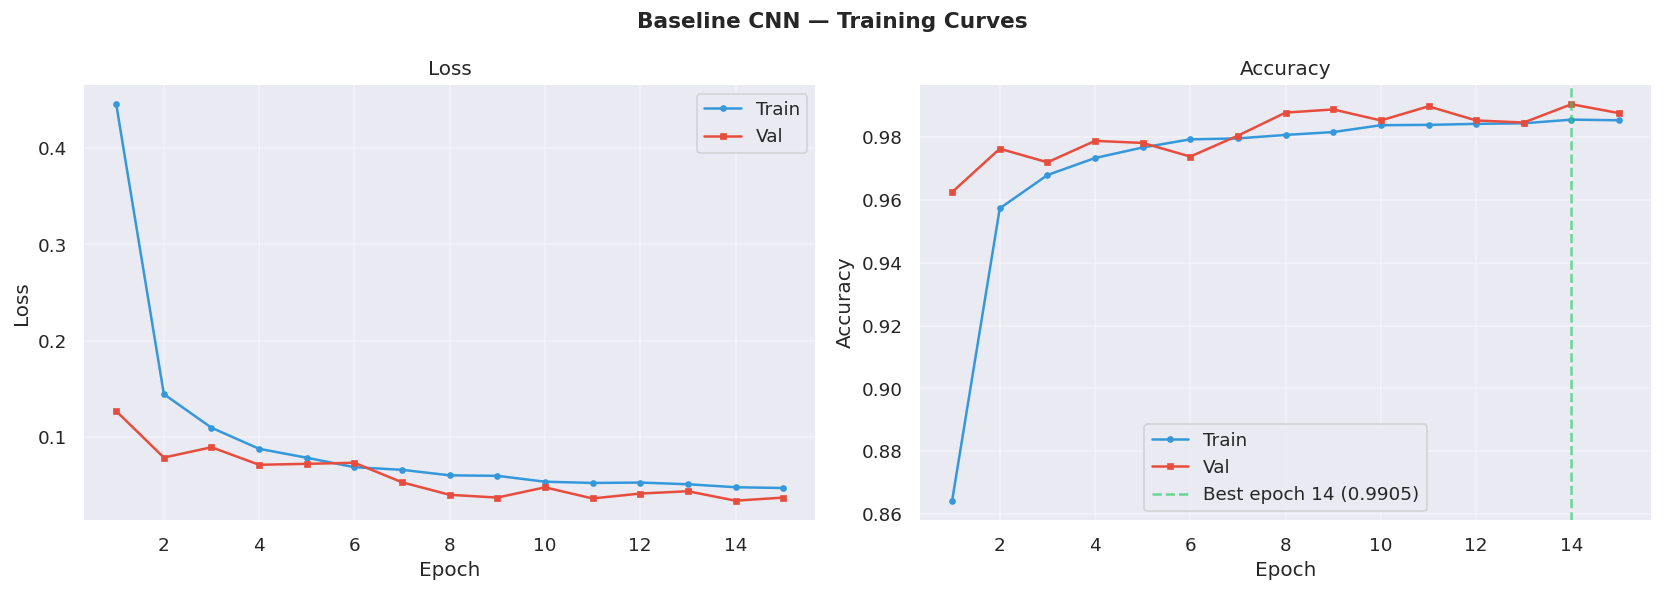

In [12]:
plot_curves(b_history, 'Baseline CNN — Training Curves',
            OUTPUT_DIR / 'baseline_training_curves.png')

---
# SECTION 2 — ResNet-18 (Adapted for MNIST)

##  Cell 7 — ResNet-18 Architecture

In [13]:
def build_resnet(num_classes: int, pretrained: bool = False) -> nn.Module:
    """
    ResNet-18 adapted for MNIST (grayscale 28×28 input).

    Two key changes from standard ResNet-18:
    1. First conv: kernel 7×7 stride 2 → kernel 3×3 stride 1 (MNIST is small)
    2. Remove MaxPool after first conv (would shrink 28×28 too aggressively)
    3. Input channels: 3 → 1 (grayscale)
    4. Final FC: 1000 → num_classes
    """
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model   = models.resnet18(weights=weights)

    # Adapt first conv for grayscale 28×28
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()          # remove aggressive pooling

    # Replace final FC layer
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model


resnet = build_resnet(NUM_CLASSES, pretrained=False).to(DEVICE)

total_p = sum(p.numel() for p in resnet.parameters())
print(f'ResNet-18 (adapted for MNIST)')
print(f'  Total parameters : {total_p:,}')
print(f'  First conv       : {resnet.conv1}')
print(f'  Classifier head  : {resnet.fc}')

ResNet-18 (adapted for MNIST)
  Total parameters : 11,172,810
  First conv       : Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  Classifier head  : Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=10, bias=True)
)


##  Cell 8 — Train ResNet-18

In [14]:
RESNET_EPOCHS = 20

r_criterion = nn.CrossEntropyLoss()
r_optimizer = optim.AdamW(resnet.parameters(), lr=1e-3, weight_decay=1e-4)
r_scheduler = optim.lr_scheduler.CosineAnnealingLR(r_optimizer, T_max=RESNET_EPOCHS)
r_scaler    = torch.cuda.amp.GradScaler()

r_history   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_r_acc  = 0.0
best_r_wts  = copy.deepcopy(resnet.state_dict())

print(f'Training ResNet-18 for {RESNET_EPOCHS} epochs on {DEVICE}...')
print('─' * 65)

t0 = time.time()
for epoch in range(1, RESNET_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(resnet, train_loader, r_criterion, r_optimizer, r_scaler)
    v_loss, v_acc, _, _, _ = evaluate(resnet, val_loader, r_criterion)
    r_history['train_loss'].append(t_loss)
    r_history['train_acc'].append(t_acc)
    r_history['val_loss'].append(v_loss)
    r_history['val_acc'].append(v_acc)
    r_scheduler.step()
    marker = ''
    if v_acc > best_r_acc:
        best_r_acc = v_acc
        best_r_wts = copy.deepcopy(resnet.state_dict())
        torch.save(best_r_wts, MODEL_DIR / 'resnet_best.pth')
        marker = '  ← best'
    print(f'  Epoch {epoch:>2}/{RESNET_EPOCHS}  '
          f'| Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f}  '
          f'| Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}{marker}')

print('─' * 65)
print(f' Done in {(time.time()-t0)/60:.1f} min  |  Best Val Acc: {best_r_acc:.4f}')
resnet.load_state_dict(best_r_wts)

Training ResNet-18 for 20 epochs on cuda...
─────────────────────────────────────────────────────────────────


  Train:   0%|          | 0/844 [00:00<?, ?it/s]

  Eval :   0%|          | 0/94 [00:00<?, ?it/s]

  Epoch  1/20  | Train Loss: 0.1542  Acc: 0.9518  | Val Loss: 0.1855  Acc: 0.9490  ← best


  Train:   0%|          | 0/844 [00:00<?, ?it/s]

...

  Epoch 19/20  | Train Loss: 0.0071  Acc: 0.9978  | Val Loss: 0.0161  Acc: 0.9962  ← best


  Train:   0%|          | 0/844 [00:00<?, ?it/s]

  Eval :   0%|          | 0/94 [00:00<?, ?it/s]

  Epoch 20/20  | Train Loss: 0.0067  Acc: 0.9979  | Val Loss: 0.0157  Acc: 0.9957
─────────────────────────────────────────────────────────────────
 Done in 8.3 min  |  Best Val Acc: 0.9962


<All keys matched successfully>

##  Cell 9 — ResNet Training Curves

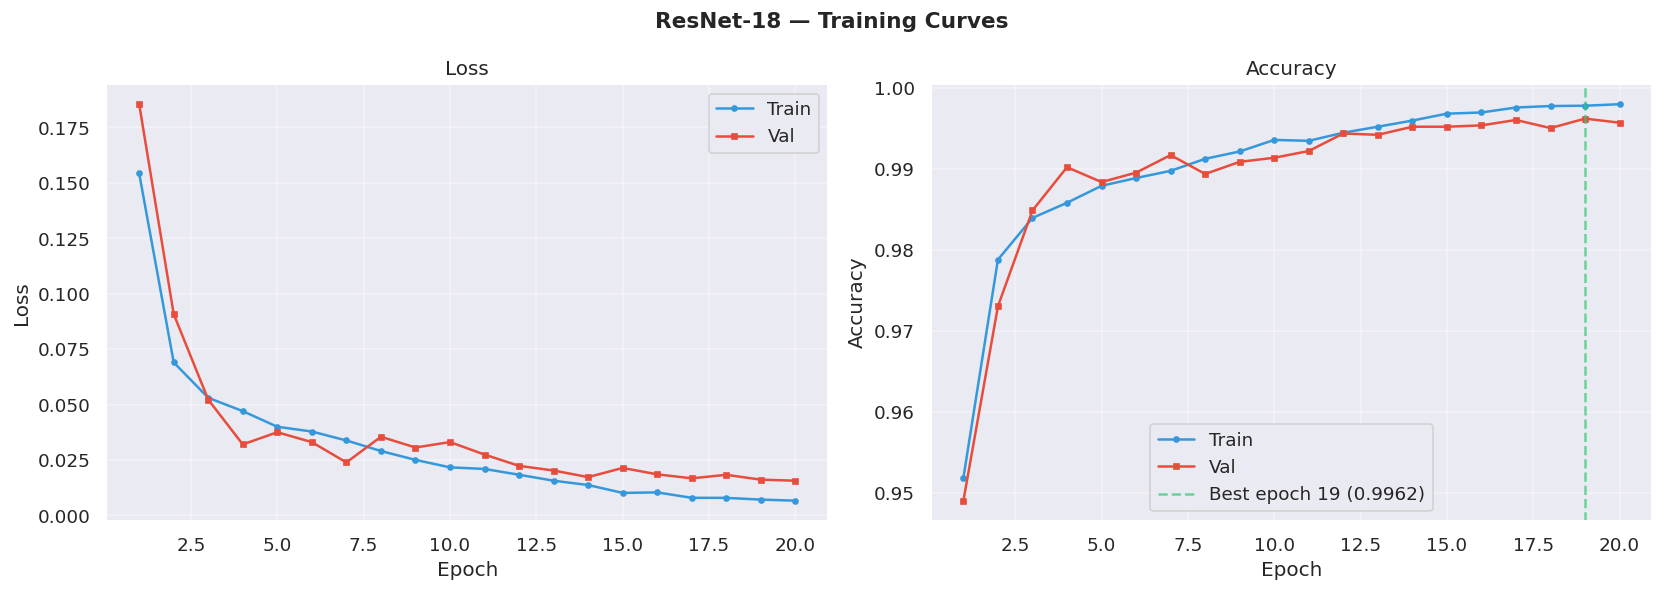

In [15]:
plot_curves(r_history, 'ResNet-18 — Training Curves',
            OUTPUT_DIR / 'resnet_training_curves.png')

---
#  SECTION 3 — Evaluation

##  Cell 10 — Test Set Inference

In [16]:
baseline.load_state_dict(torch.load(MODEL_DIR / 'baseline_best.pth', map_location=DEVICE))
resnet.load_state_dict(torch.load(MODEL_DIR / 'resnet_best.pth',    map_location=DEVICE))

_, b_acc, b_preds, b_labels, b_probs = evaluate(baseline, test_loader, b_criterion)
_, r_acc, r_preds, r_labels, r_probs = evaluate(resnet,   test_loader, r_criterion)

b_f1 = f1_score(b_labels, b_preds, average='macro')
r_f1 = f1_score(r_labels, r_preds, average='macro')

print(f'  Baseline CNN  → Test Acc: {b_acc:.4f}  Macro F1: {b_f1:.4f}')
print(f'  ResNet-18     → Test Acc: {r_acc:.4f}  Macro F1: {r_f1:.4f}')

  Eval :   0%|          | 0/157 [00:00<?, ?it/s]

  Eval :   0%|          | 0/157 [00:00<?, ?it/s]

  Baseline CNN  → Test Acc: 0.9919  Macro F1: 0.9919
  ResNet-18     → Test Acc: 0.9970  Macro F1: 0.9970


##  Cell 11 — Classification Reports

In [17]:
print('=' * 55)
print('BASELINE CNN — Classification Report')
print('=' * 55)
print(classification_report(b_labels, b_preds, target_names=CLASS_NAMES))

print('=' * 55)
print('RESNET-18 — Classification Report')
print('=' * 55)
print(classification_report(r_labels, r_preds, target_names=CLASS_NAMES))

BASELINE CNN — Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      1.00      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

RESNET-18 — Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
       

##  Cell 12 — Confusion Matrices

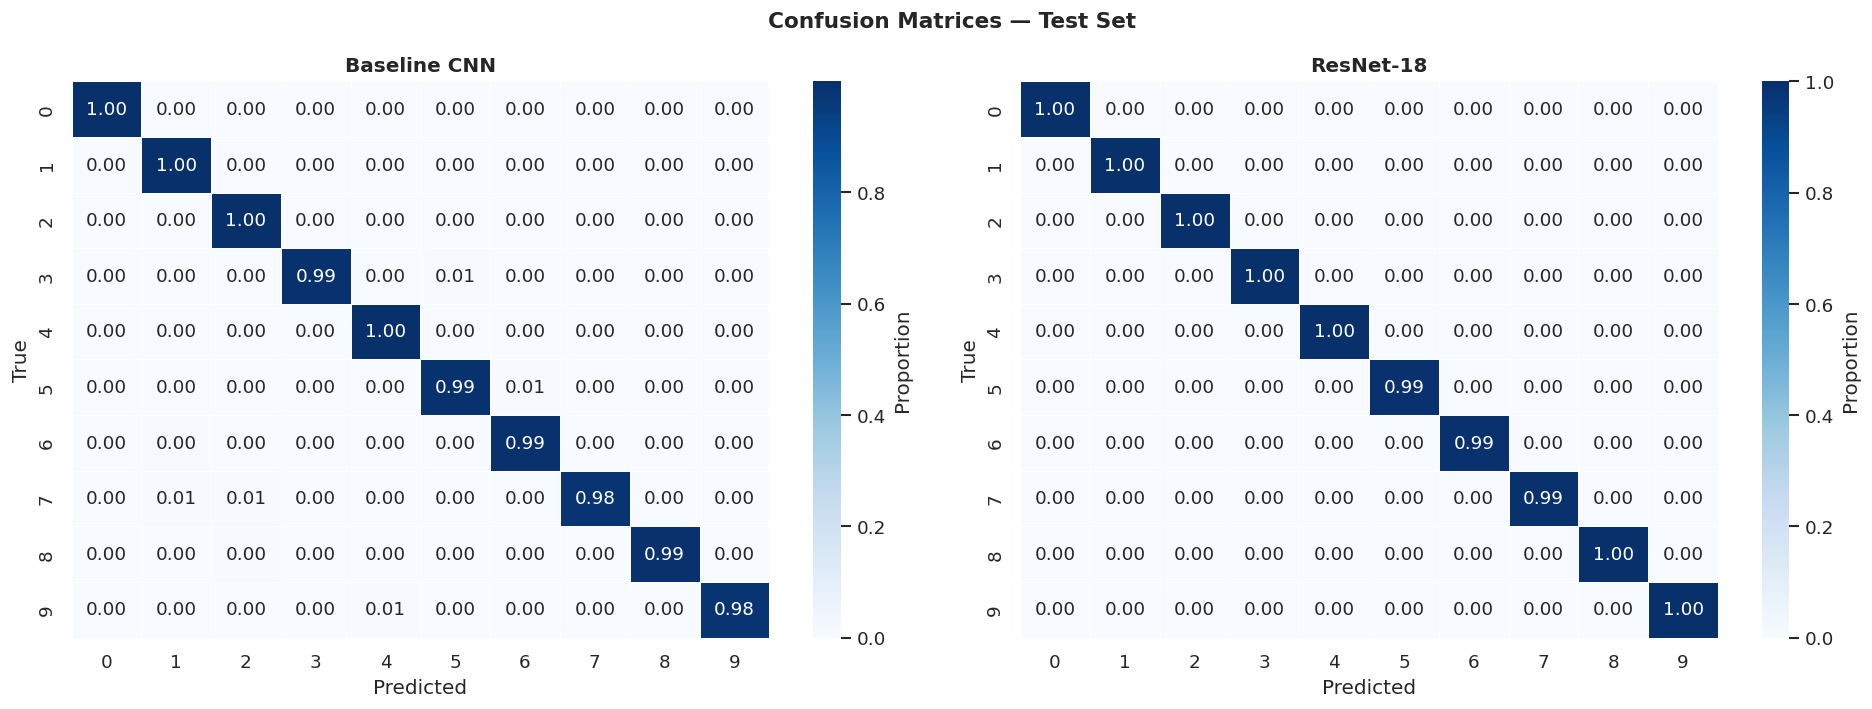

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')

for ax, preds, labels, title in zip(
    axes,
    [b_preds, r_preds],
    [b_labels, r_labels],
    ['Baseline CNN', 'ResNet-18']
):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Proportion'})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

##  Cell 13 — Per-Class F1 Comparison

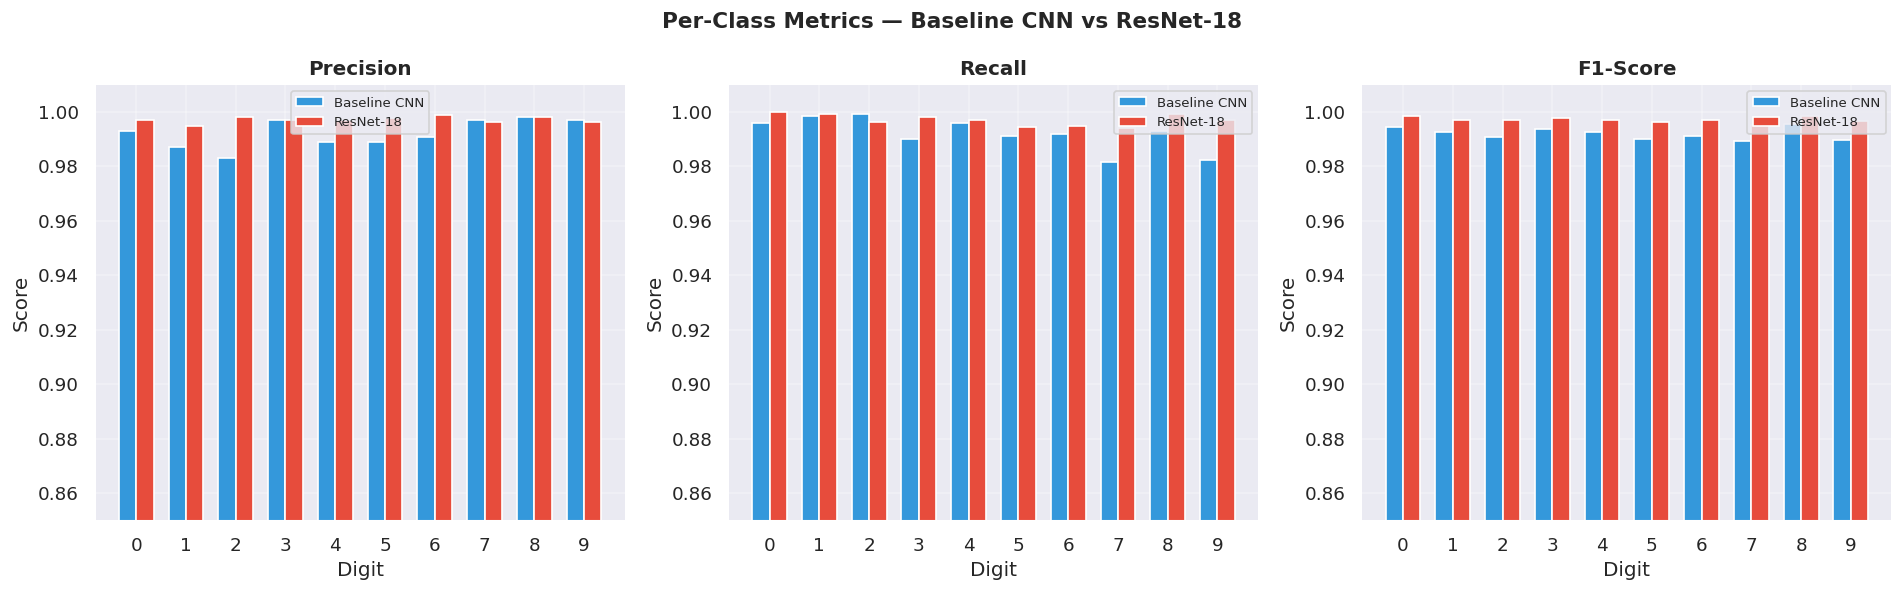

In [19]:
from sklearn.metrics import precision_recall_fscore_support

b_prec, b_rec, b_f1pc, _ = precision_recall_fscore_support(b_labels, b_preds)
r_prec, r_rec, r_f1pc, _ = precision_recall_fscore_support(r_labels, r_preds)

x     = np.arange(NUM_CLASSES)
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Per-Class Metrics — Baseline CNN vs ResNet-18', fontsize=13, fontweight='bold')

for ax, b_vals, r_vals, metric in zip(
    axes,
    [b_prec, b_rec, b_f1pc],
    [r_prec, r_rec, r_f1pc],
    ['Precision', 'Recall', 'F1-Score']
):
    ax.bar(x - width/2, b_vals, width, label='Baseline CNN', color='#3498db', edgecolor='white')
    ax.bar(x + width/2, r_vals, width, label='ResNet-18',    color='#e74c3c', edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Digit')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylim(0.85, 1.01)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_metrics.png', bbox_inches='tight')
plt.show()

##  Cell 14 — Misclassified Examples

ResNet-18 misclassified : 30 / 10000 test images
Error rate              : 0.30%


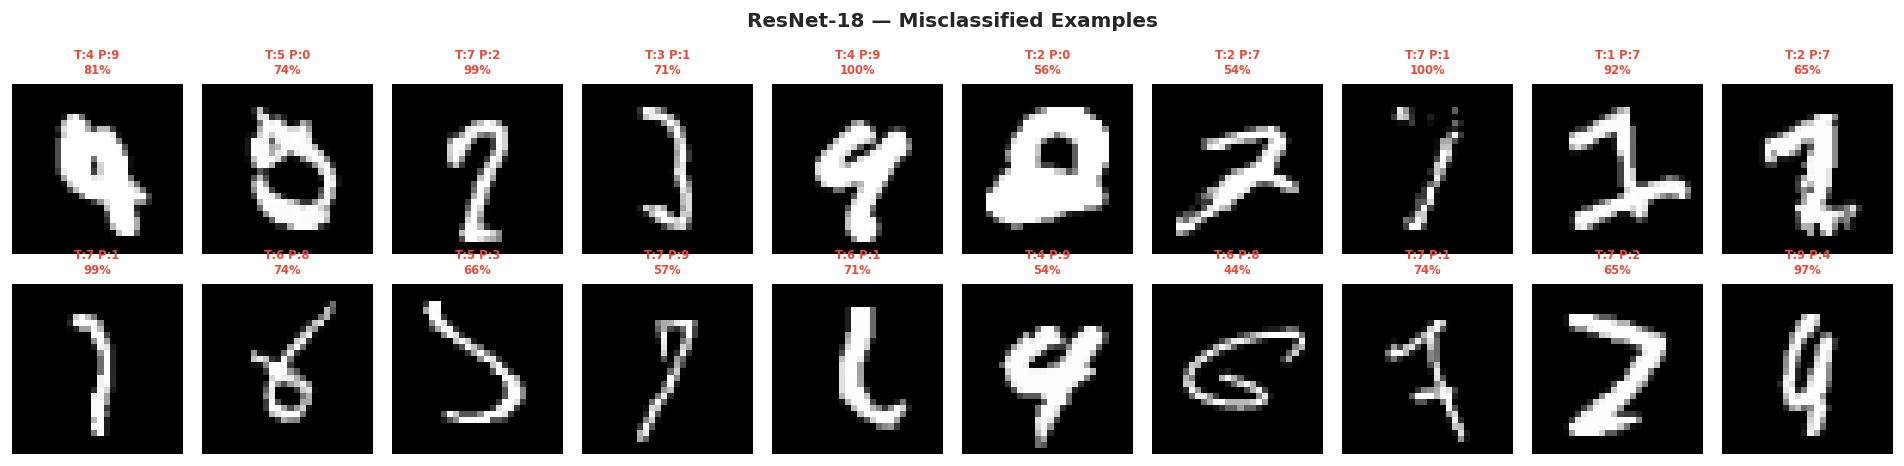

In [20]:
# Show misclassified images from ResNet 
wrong_mask = r_preds != r_labels
wrong_idx  = np.where(wrong_mask)[0]
print(f'ResNet-18 misclassified : {wrong_mask.sum()} / {len(r_labels)} test images')
print(f'Error rate              : {wrong_mask.mean()*100:.2f}%')

N_SHOW   = min(20, len(wrong_idx))
chosen   = np.random.choice(wrong_idx, N_SHOW, replace=False)

# Get actual test images 
all_test_imgs  = torch.stack([test_data[i][0] for i in range(len(test_data))])

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('ResNet-18 — Misclassified Examples', fontsize=12, fontweight='bold')

for ax, idx in zip(axes.flatten(), chosen):
    img       = all_test_imgs[idx]
    true_lbl  = r_labels[idx]
    pred_lbl  = r_preds[idx]
    conf      = r_probs[idx][pred_lbl] * 100
    ax.imshow(denormalize(img).squeeze(), cmap='gray')
    ax.set_title(f'T:{true_lbl} P:{pred_lbl}\n{conf:.0f}%',
                 fontsize=7, color='#e74c3c', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resnet_misclassified.png', bbox_inches='tight')
plt.show()

##  Cell 15 — Model Comparison Table

  MODEL COMPARISON — TEST SET
                 Baseline CNN  ResNet-18       Δ
Metric                                          
Accuracy               0.9919     0.9970  0.0051
Macro Precision        0.9920     0.9971  0.0051
Macro Recall           0.9918     0.9970  0.0052
Macro F1               0.9919     0.9970  0.0051


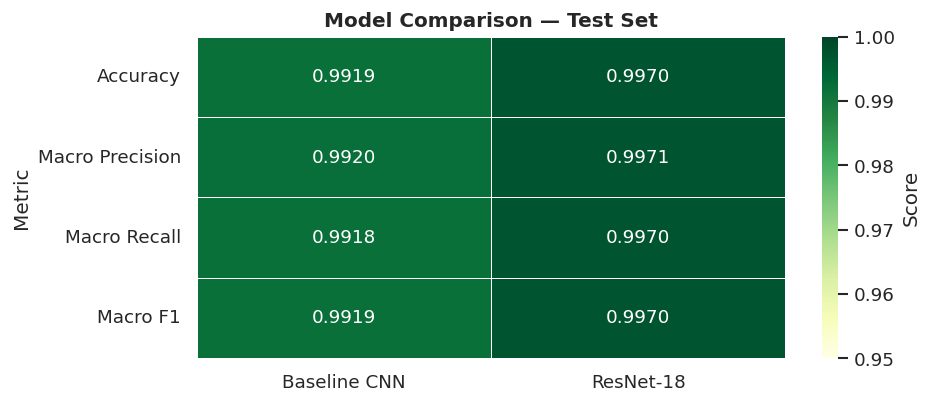

In [21]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def get_summary(labels, preds):
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    return {'Accuracy': round(acc,4), 'Macro Precision': round(p,4),
            'Macro Recall': round(r,4), 'Macro F1': round(f1,4)}

b_sum = get_summary(b_labels, b_preds)
r_sum = get_summary(r_labels, r_preds)

comp_df = pd.DataFrame({
    'Metric'      : list(b_sum.keys()),
    'Baseline CNN': list(b_sum.values()),
    'ResNet-18'   : list(r_sum.values()),
    'Δ'           : [round(r-b, 4) for b, r in zip(b_sum.values(), r_sum.values())]
}).set_index('Metric')

print('=' * 55)
print('  MODEL COMPARISON — TEST SET')
print('=' * 55)
print(comp_df.to_string())
print('=' * 55)

comp_df.to_csv(OUTPUT_DIR / 'model_comparison.csv')

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(comp_df[['Baseline CNN','ResNet-18']].astype(float),
            annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.95, vmax=1.0, linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Score'})
ax.set_title('Model Comparison — Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_heatmap.png', bbox_inches='tight')
plt.show()

## Cell 16 — Save Inference Bundle

In [22]:
torch.save({
    'model_state_dict' : resnet.state_dict(),
    'architecture'     : 'resnet18_mnist',
    'num_classes'      : NUM_CLASSES,
    'class_names'      : CLASS_NAMES,
    'img_size'         : IMG_SIZE,
    'channels'         : 1,
    'mnist_mean'       : MNIST_MEAN,
    'mnist_std'        : MNIST_STD,
    'test_accuracy'    : r_sum['Accuracy'],
    'test_macro_f1'    : r_sum['Macro F1'],
}, MODEL_DIR / 'resnet_inference.pth')

print(' Inference bundle saved:')
for f in sorted(MODEL_DIR.iterdir()):
    print(f'   {f.name:<40} {f.stat().st_size/1e6:.1f} MB')

 Inference bundle saved:
   baseline_best.pth                        0.4 MB
   resnet_best.pth                          44.8 MB
   resnet_inference.pth                     44.8 MB


---
##  Cell 17 — Final Summary

In [24]:
print('═' * 60)
print('  MNIST DIGIT RECOGNIZER — NOTEBOOK 2 COMPLETE')
print('═' * 60)
print(f'  Baseline CNN  →  Acc: {b_sum["Accuracy"]:.4f}  F1: {b_sum["Macro F1"]:.4f}')
print(f'  ResNet-18     →  Acc: {r_sum["Accuracy"]:.4f}  F1: {r_sum["Macro F1"]:.4f}')
print()
print('  Saved artifacts:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'    outputs/{f.name}')
print()
print('    models/baseline_best.pth')
print('    models/resnet_best.pth')
print('    models/resnet_inference.pth  ← use this for FastAPI')
print()

print('═' * 60)

════════════════════════════════════════════════════════════
  MNIST DIGIT RECOGNIZER — NOTEBOOK 2 COMPLETE
════════════════════════════════════════════════════════════
  Baseline CNN  →  Acc: 0.9919  F1: 0.9919
  ResNet-18     →  Acc: 0.9970  F1: 0.9970

  Saved artifacts:
    outputs/.ipynb_checkpoints
    outputs/baseline_training_curves.png
    outputs/confusion_matrices.png
    outputs/dataset_meta.json
    outputs/eda_average_digits.png
    outputs/eda_class_distribution.png
    outputs/eda_pixel_distribution.png
    outputs/eda_sample_images.png
    outputs/eda_style_variation.png
    outputs/model_comparison.csv
    outputs/model_comparison_heatmap.png
    outputs/per_class_metrics.png
    outputs/preprocessing_augmentation.png
    outputs/preprocessing_batch_sample.png
    outputs/resnet_misclassified.png
    outputs/resnet_training_curves.png

    models/baseline_best.pth
    models/resnet_best.pth
    models/resnet_inference.pth  ← use this for FastAPI

═════════════════════